In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
csv_file = Path("../data/customer_support_tickets.csv")
csv_f = "../data/customer_support_tickets.csv"
print(csv_file)
print(csv_f)

df = pd.read_csv(csv_file)
df.head()

..\data\customer_support_tickets.csv
../data/customer_support_tickets.csv


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
df['Ticket_Description'] = df.apply(lambda row: str(row['Ticket Description']).replace('{product_purchased}', str(row['Product Purchased'])), axis=1)

print(df[['Ticket Description', 'Ticket_Description']].head())

                                                                                                                                                                                                                                                                                                                                       Ticket Description  \
0                                          I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.   
1                                            I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fin

In [23]:
def cleaning_descrn(row):
    text = str(row['Ticket_Description']).lower().strip()
    
    #find anything inside {{ }} or { } and replace it with the Product Name
    product = str(row['Product Purchased'])
    text = re.sub(r'\{+.*?product_?purchased.*?\}+', product, text)
    
    # Since we don't have a column for 'error_message' - doubt
    # text = re.sub(r'\{+.*?error_message.*?\}+', '?', text)
    
    # Removes html tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Removes \r, \n, #, _, and extra brackets - } ]
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'[#__{}\[\]]', ' ', text)
    
    text = text.lower().strip()

    # Shrink multiple spaces to one
    text = re.sub(r'\s+', ' ', text) 
    
    return text

df['Ticket_Description'] = df.apply(cleaning_descrn, axis=1)



In [24]:
# Check if any other curly brackets exist in the data - yet to work on it
remaining_placeholders = df['Ticket_Description'].str.contains(r'\{.*\}')
df[remaining_placeholders]['Ticket_Description']

# 27, 59, 64,65,70,8398, 8416, 8421, 8441, 8447

Series([], Name: Ticket_Description, dtype: str)

In [25]:

df.loc[[27, 59, 64,65,70,8398, 8416, 8421, 8441, 8447], 'Ticket_Description'].values

<StringArray>
[                                                                             'i'm having an issue with the fitbit charge. please assist. fitbit charge must be a valid email address for your order and are valid for one week in advance. please make your purchases as quickly as possible the issue i'm facing is intermittent. sometimes it works fine, but other times it acts up unexpectedly.',
                                                                                           'i'm having an issue with the apple airpods. please assist. also note: your information gets deleted every time an article is sent to a website you've never viewed. product id is a unique identifier in i'm not sure if this issue is specific to my device or if others have reported similar problems.',
                                   'i'm facing a problem with my microsoft xbox controller. the microsoft xbox controller is not turning on. it was working fine until yesterday, but now it doesn't respo

In [27]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket_Description,word_count
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,"i'm having an issue with the gopro hero. please assist. your billing zip code is: 71701. we appreciate that you have requested a website address. please double check your email address. i've tried troubleshooting steps mentioned in the user manual, but the issue persists.",44
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,"i'm having an issue with the lg smart tv. please assist. if you need to change an existing product. i'm having an issue with the lg smart tv. please assist. if the issue i'm facing is intermittent. sometimes it works fine, but other times it acts up unexpectedly.",48
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,"i'm facing a problem with my dell xps. the dell xps is not turning on. it was working fine until yesterday, but now it doesn't respond. 1.8.3 i really i'm using the original charger that came with my dell xps, but it's not charging properly.",45
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,"i'm having an issue with the microsoft office. please assist. if you have a problem you're interested in and i'd love to see this happen, please check out the feedback. i've already contacted customer support multiple times, but the issue remains unresolved.",42
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,i'm having an issue with the autodesk autocad. please assist. note: the seller is not responsible for any 

In [ ]:
# word count

df['word_count'] = df['Ticket_Description'].apply(lambda x: len(str(x).split()))


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket_Description,word_count


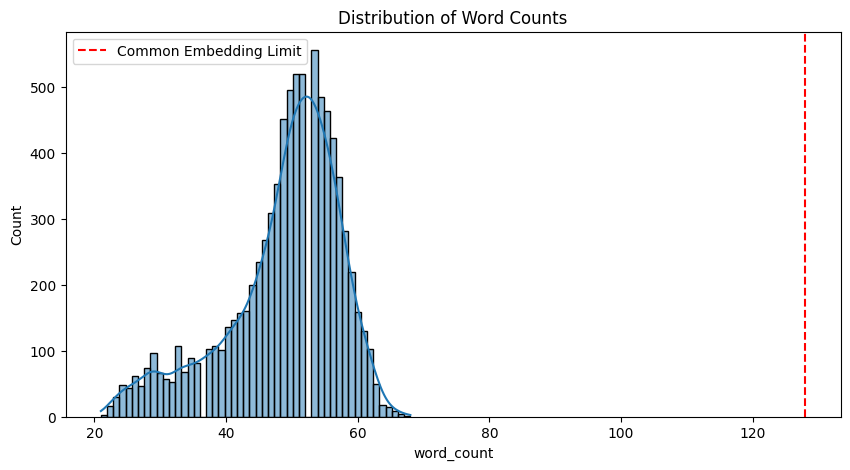

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Counts')
plt.axvline(x=128, color='r', linestyle='--', label='Common Embedding Limit')
plt.legend()
plt.show()

In [21]:
# duplicates check

duplicates = df[df.duplicated(subset=['Ticket_Description'], keep=False)]
duplicates

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket_Description,word_count
105,106,Virginia Miller,lisahamilton@example.com,56,Other,Dyson Vacuum Cleaner,2021-07-17,Product inquiry,Battery life,I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.,Pending Customer Response,NaN,Critical,Chat,2023-06-01 02:08:01,NaN,NaN,i'm having an issue with the dyson vacuum cleaner. please assist. i need assistance as soon as possible because it's affecting my work and productivity.,25
250,251,Zachary Weiss,cindy89@example.org,19,Female,Roomba Robot Vacuum,2021-07-27,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist. I'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem.",Closed,Heavy old particular something.,Critical,Phone,2023-06-01 03:15:34,2023-06-01 08:04:34,2.0,"i'm having an issue with the roomba robot vacuum. please assist. i'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem.",30
267,268,Bruce Morales,nelsonrichard@example.com,37,Male,Google Nest,2020-02-22,Technical issue,Product recommendation,I'm having an issue with the {product_purchased}. Please assist. I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.,Open,NaN,Low,Social media,NaN,NaN,NaN,i'm having an issue with the google nest. please assist. i'm concerned about the security of my google nest and would like to ensure that my data is safe.,29
268,269,Dennis Miller,ytownsend@example.net,69,Female,Microsoft Surface,2020-08-21,Cancellation request,Refund request,"I'm having an issue with the {product_purchased}. Please assist. I've reviewed the troubleshooting steps on the official support website, but they didn't resolve the problem.",Pending Customer Response,NaN,Medium,Phone,2023-06-01 08:03:56,NaN,NaN,"i'm having an issue with the microsoft surface. please assist. i've reviewed the troubleshooting steps on the official support website, but they didn't resolve the problem.",26
287,288,Patrick Thomas,kingtricia@example.net,37,Other,LG OLED,2020-07-06,Product inquiry,Product setup,I'm having an issue with the {product_purchased}. Please assist. I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}.,Open,NaN,Low,Email,NaN,NaN,NaN,i'm having an issue with the lg oled. please assist. i've noticed that the issue occurs consistently when i use a specific feature or application on my lg oled.,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8227,8228,Angela Gray,adamtaylor@example.com,18,Male,HP Pavilion,2021-09-28,Refund request,Product recommendation,"I'm having an issue with the {product_purchased}. Please assist. I've followed the troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,NaN,Medium,Social media,2023-06-01 04:56:57,NaN,NaN,"i'm having an issue with the hp pavilion. please assist. i've followed the troubleshooting steps mentioned in the user manual, but the issue persists.",24
8270,8271,Jeffrey Leon,adavidson@example.org,24,Female,LG Smart TV,2020-07-12,Technical issue,Refund request,I'm having an issue with the {product_purchased}. Please assist. I'm worried that the issue might be hardware-related and might require repair or replacement.,Pending Customer Response,NaN,Critical,Social media,2023-06-01 19:55:57,NaN,NaN,i'm having an issue with the lg smart tv. please assist. i'm worried that the issue might be hardware-related and might require repair or replacement.,25
8386,8387,Caitlin Robinson,bsm

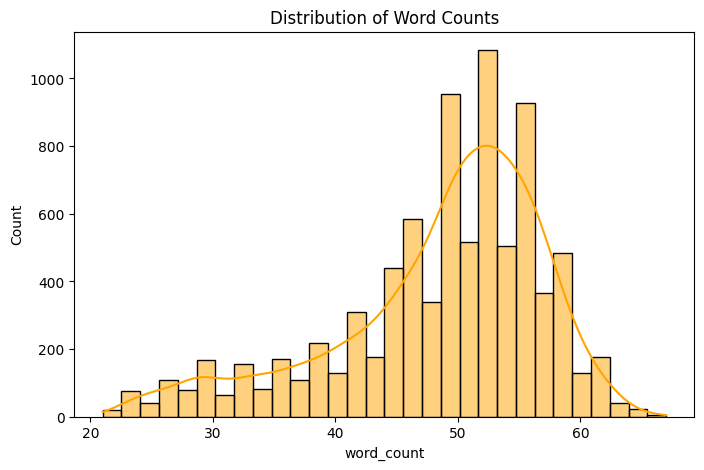

Average words per ticket: 48.54


In [6]:
import seaborn as sns

df['word_count'] = df['Ticket_Description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=True, color='orange')
plt.title('Distribution of Word Counts')
plt.show()

print(f"Average words per ticket: {df['word_count'].mean():.2f}")

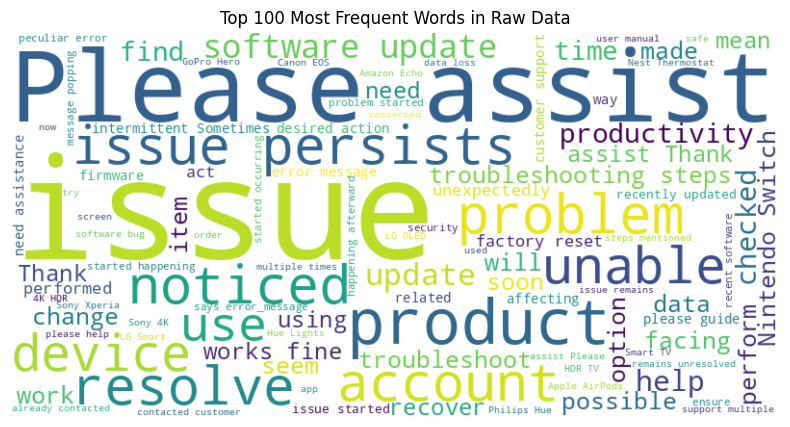

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text into one giant string
all_text = " ".join(df['Ticket_Description'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words in Raw Data')
plt.show()